
# Landslide Segmentation — Full Results & Reproduction Visualization

This notebook is an internal research-analysis notebook for:

1. **Landslide4Sense public benchmark sanity check**
   - official reported baseline,
   - our `reported-validation` reproduction,
   - our `literal-source` reproduction,
   - training history,
   - pooled confusion/error statistics,
   - per-image distributions,
   - qualitative validation masks,
   - prediction agreement between reproductions.

2. **Tillamook strict-binary development experiment**
   - 2×2 depth × feature comparison,
   - Dice / IoU / precision / recall / specificity,
   - FP/FN burden,
   - predicted-positive vs GT-positive prevalence,
   - training curves,
   - threshold sweeps,
   - detailed `deep_7ch` operating-point analysis.

3. **Context comparison**
   - Landslide4Sense and Tillamook are shown together only for debugging context.
   - They are **not directly comparable benchmarks** because datasets, inputs, resolution, losses, class prevalence, architectures, and evaluation protocols differ.

**Important:** this notebook does not load or evaluate the locked Tillamook internal test split.


In [116]:

from pathlib import Path
import json
import math
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
# If the notebook is opened somewhere else, uncomment:
# ROOT = Path(r"F:\LIDAR\oregon")

# ---------- Landslide4Sense ----------
L4S_ROOT = Path(r"F:\LIDAR\public_benchmarks\Landslide4sense")

L4S_REPORTED_RUN = ROOT / "public_benchmark_l4s" / "ours_reproduction"
L4S_LITERAL_RUN = ROOT / "public_benchmark_l4s" / "ours_literal_official"

L4S_REPORTED_METRICS = L4S_REPORTED_RUN / "metrics.json"
L4S_LITERAL_METRICS = L4S_LITERAL_RUN / "metrics.json"

L4S_REPORTED_HISTORY = L4S_REPORTED_RUN / "history.csv"
L4S_LITERAL_HISTORY = L4S_LITERAL_RUN / "history.csv"

L4S_GT_DIR = L4S_ROOT / "annotations" / "validation"
L4S_IMAGE_DIR = L4S_ROOT / "images" / "validation"

L4S_REPORTED_PRED = L4S_REPORTED_RUN / "validation_predictions"
L4S_LITERAL_PRED = L4S_LITERAL_RUN / "validation_predictions"

# ---------- Tillamook ----------
TILLAMOOK_PHASE3 = ROOT / "dataset_tillamook_100_binary_15m_split641620"
TILLAMOOK_PHASE4 = ROOT / "phase4_tillamook_binary_2x2"

TILLAMOOK_RUNS = {
    "shallow_7ch": TILLAMOOK_PHASE4 / "shallow_7ch",
    "shallow_3ch": TILLAMOOK_PHASE4 / "shallow_3ch",
    "deep_7ch": TILLAMOOK_PHASE4 / "deep_7ch",
    "deep_3ch": TILLAMOOK_PHASE4 / "deep_3ch",
}

FIGDIR = ROOT / "analysis_figures_full"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Figure output:", FIGDIR)
print()
print("L4S literal metrics exists:", L4S_LITERAL_METRICS.exists())
print("L4S reported-validation metrics exists:", L4S_REPORTED_METRICS.exists())
print("Tillamook comparison exists:", (TILLAMOOK_PHASE4 / "comparison.csv").exists())


ROOT: f:\LIDAR\oregon
Figure output: f:\LIDAR\oregon\analysis_figures_full

L4S literal metrics exists: True
L4S reported-validation metrics exists: True
Tillamook comparison exists: True


## Model input preview
Four positive Landslide4Sense validation tiles showing the image input, additional channel views, and whether the prediction is right or wrong versus the ground truth.


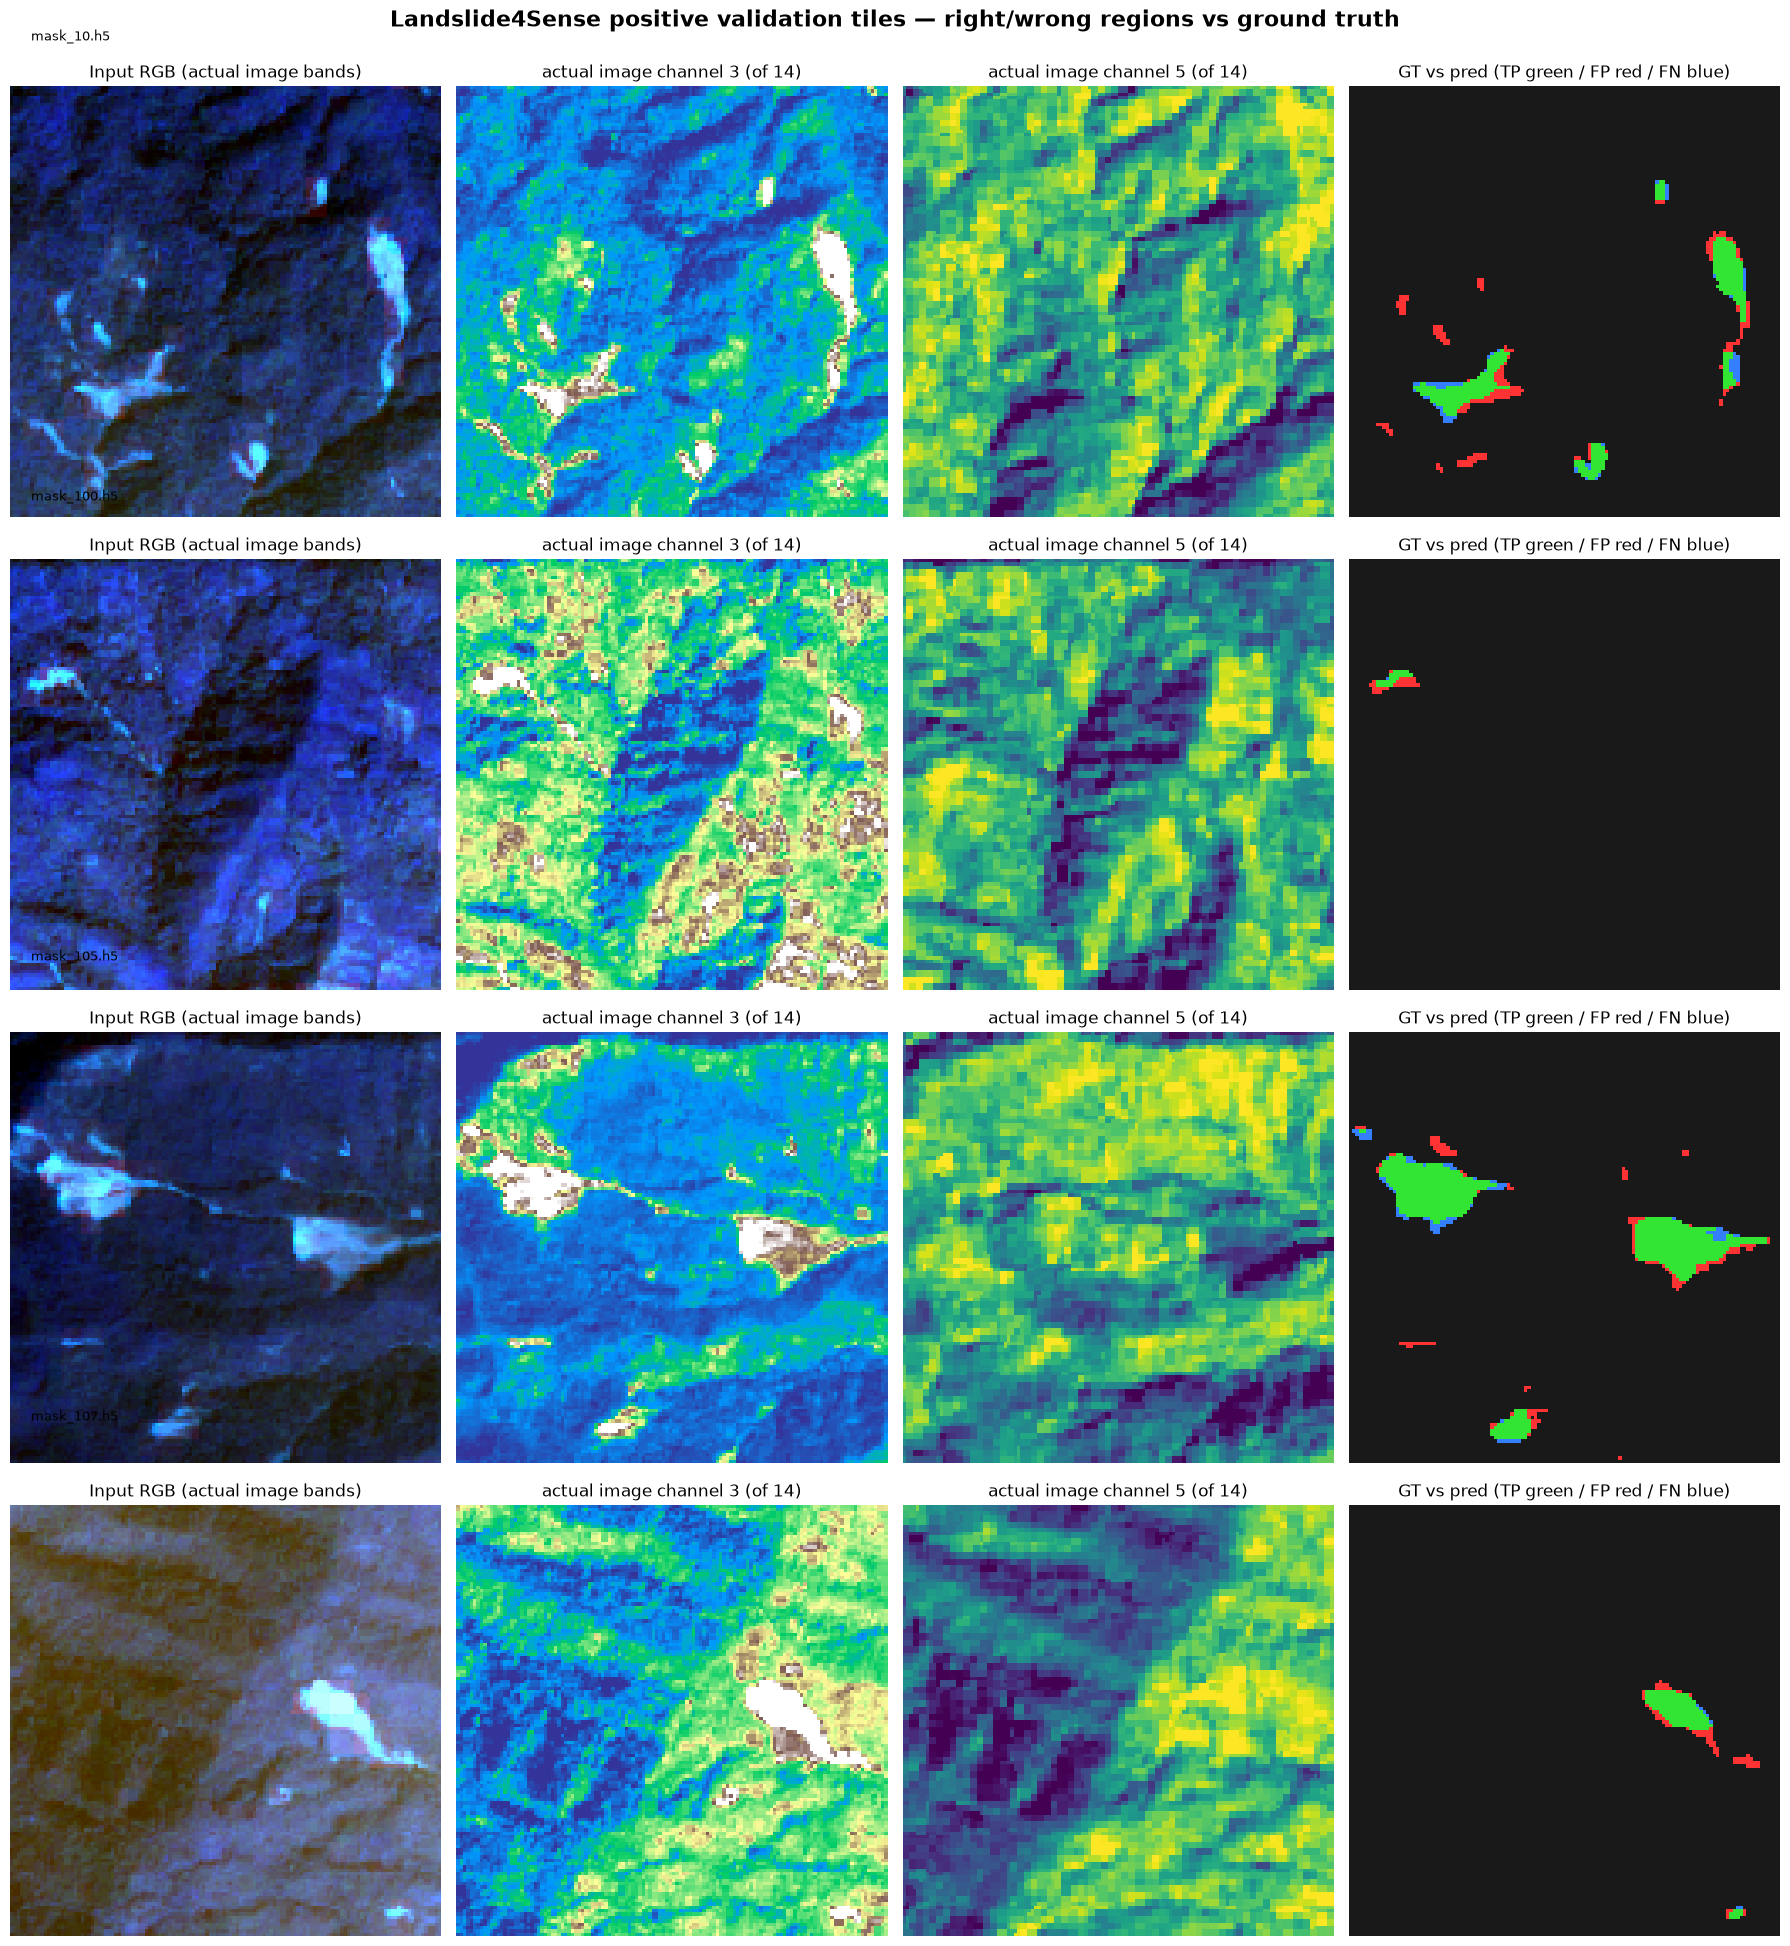

Displayed 4 positive Landslide4Sense validation tiles with GT-vs-pred overlay.
mask_10.h5: TP=425, FP=215, FN=80
mask_100.h5: TP=26, FP=31, FN=1
mask_105.h5: TP=839, FP=162, FN=98
mask_107.h5: TP=158, FP=79, FN=7


In [117]:

# Four positive Landslide4Sense validation tiles.
# Each row shows: RGB input, DEM-like channel, another terrain/context channel,
# and a GT-vs-prediction error overlay (green TP / red FP / blue FN).


def read_h5_array(path):
    with h5py.File(path, "r") as hf:
        if "mask" in hf:
            arr = hf["mask"][:]
        elif "img" in hf:
            arr = hf["img"][:]
        elif len(hf.keys()) == 1:
            arr = hf[list(hf.keys())[0]][:]
        else:
            raise KeyError(f"Unsupported HDF5 structure in {path}")
    return np.asarray(arr)


def make_rgb(image):
    arr = np.asarray(image)
    if arr.ndim == 3 and arr.shape[0] in (13, 14):
        arr = np.moveaxis(arr, 0, -1)
    if arr.ndim == 2:
        arr = np.repeat(arr[..., None], 3, axis=-1)
    if arr.shape[-1] >= 3:
        rgb = arr[..., :3]
    else:
        rgb = np.repeat(arr[..., None], 3, axis=-1)
    lo, hi = np.nanpercentile(rgb, [1, 99])
    rgb = np.clip(rgb, lo, hi)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb


def channel_display(arr, idx):
    x = np.asarray(arr)
    if x.ndim == 3 and x.shape[0] in (13, 14):
        x = np.moveaxis(x, 0, -1)
    if x.ndim == 2:
        return x
    if x.shape[-1] > idx:
        x = x[..., idx]
    else:
        x = x[..., 0]
    lo, hi = np.nanpercentile(x, [2, 98])
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return x


def actual_channel_label(arr, idx):
    """Return labels that match the real array content instead of inventing DEM-like semantics."""
    x = np.asarray(arr)
    if x.ndim == 3 and x.shape[0] in (13, 14):
        x = np.moveaxis(x, 0, -1)
    if x.ndim == 2:
        return "single-band raster"
    n_channels = x.shape[-1] if x.ndim == 3 else 1
    if n_channels <= 1:
        return "single-band raster"
    if idx < 0:
        idx = 0
    idx = min(idx, n_channels - 1)
    if n_channels >= 3 and idx == 0:
        return f"input image / first 3 bands (actual array channels 0:3)"
    return f"actual image channel {idx} (of {n_channels})"


def error_overlay(gt, pred):
    gt = np.asarray(gt, dtype=np.uint8)
    pred = np.asarray(pred, dtype=np.uint8)
    overlay = np.zeros((*gt.shape, 3), dtype=np.float32)
    tp = (gt == 1) & (pred == 1)
    fp = (gt == 0) & (pred == 1)
    fn = (gt == 1) & (pred == 0)
    tn = (gt == 0) & (pred == 0)
    overlay[tp] = [0.2, 0.9, 0.2]
    overlay[fp] = [1.0, 0.2, 0.2]
    overlay[fn] = [0.2, 0.5, 1.0]
    overlay[tn] = [0.10, 0.10, 0.10]
    return overlay


def corresponding_image(mask_name):
    return L4S_IMAGE_DIR / mask_name.replace("mask_", "image_", 1)


# Use the literal-source run by default because it is the actual source-code reproduction.
pred_dir = L4S_LITERAL_PRED if L4S_LITERAL_PRED.exists() else L4S_REPORTED_PRED
if not pred_dir.exists():
    raise FileNotFoundError(f"No prediction directory found under {ROOT}")

selected = []
for gt_path in sorted(L4S_GT_DIR.glob("mask_*.h5")):
    pred_path = pred_dir / gt_path.name
    if not pred_path.exists():
        continue
    gt = np.squeeze(read_h5_array(gt_path))
    if int((gt == 1).sum()) <= 0:
        continue
    selected.append((gt_path, pred_path))
    if len(selected) >= 4:
        break

if len(selected) < 4:
    raise RuntimeError(f"Found only {len(selected)} positive Landslide4Sense validation tiles; expected 4.")

fig, axes = plt.subplots(4, 4, figsize=(18, 20))
axes = axes.ravel()

for ax_index, (gt_path, pred_path) in enumerate(selected):
    row = ax_index * 4
    img_path = corresponding_image(gt_path.name)
    image = np.asarray(read_h5_array(img_path))
    gt = np.squeeze(read_h5_array(gt_path))
    pred = np.squeeze(read_h5_array(pred_path)).astype(np.uint8)

    rgb = make_rgb(image)
    dem_idx = 3 if image.shape[-1] > 3 else 0
    other_idx = 5 if image.shape[-1] > 5 else 1
    dem_channel = channel_display(image, dem_idx)
    other_channel = channel_display(image, other_idx)
    overlay = error_overlay(gt, pred)

    axes[row + 0].imshow(rgb)
    axes[row + 0].set_title("Input RGB (actual image bands)")
    axes[row + 0].axis("off")

    axes[row + 1].imshow(dem_channel, cmap="terrain")
    axes[row + 1].set_title(actual_channel_label(image, dem_idx))
    axes[row + 1].axis("off")

    axes[row + 2].imshow(other_channel, cmap="viridis")
    axes[row + 2].set_title(actual_channel_label(image, other_idx))
    axes[row + 2].axis("off")

    axes[row + 3].imshow(overlay)
    axes[row + 3].set_title("GT vs pred (TP green / FP red / FN blue)")
    axes[row + 3].axis("off")

    fig.text(0.02, 0.97 - ax_index * 0.23, gt_path.name, fontsize=9, va="top")

for i in range(len(selected) * 4, len(axes)):
    axes[i].axis("off")

fig.suptitle("Landslide4Sense positive validation tiles — right/wrong regions vs ground truth", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(FIGDIR / "l4s_positive_tiles_right_wrong.png", dpi=180, bbox_inches="tight")
plt.show()

print("Displayed 4 positive Landslide4Sense validation tiles with GT-vs-pred overlay.")
for gt_path, pred_path in selected:
    gt = np.squeeze(read_h5_array(gt_path))
    pred = np.squeeze(read_h5_array(pred_path)).astype(np.uint8)
    tp = int(((gt == 1) & (pred == 1)).sum())
    fp = int(((gt == 0) & (pred == 1)).sum())
    fn = int(((gt == 1) & (pred == 0)).sum())
    print(f"{gt_path.name}: TP={tp}, FP={fp}, FN={fn}")

### Model input preview
Single example patch: Sentinel RGB, slope, DEM-like terrain, and landslide label.


## A. Landslide4Sense — headline reproduction results

In [118]:

OFFICIAL = {
    "precision": 0.5175,
    "recall": 0.6550,
    "f1": 0.5782,
}

def load_json(path):
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None

reported_obj = load_json(L4S_REPORTED_METRICS)
literal_obj = load_json(L4S_LITERAL_METRICS)

rows = [{
    "run": "Official reported",
    "precision": OFFICIAL["precision"],
    "recall": OFFICIAL["recall"],
    "f1": OFFICIAL["f1"],
    "iou": np.nan,
    "overall_accuracy": np.nan,
    "tp": np.nan,
    "fp": np.nan,
    "fn": np.nan,
    "tn": np.nan,
}]

if reported_obj is not None:
    m = reported_obj["validation"]
    rows.append({"run": "Our reported-validation", **{k: m.get(k, np.nan) for k in
                 ["precision","recall","f1","iou","overall_accuracy","tp","fp","fn","tn"]}})

if literal_obj is not None:
    m = literal_obj["validation"]
    rows.append({"run": "Our literal-source", **{k: m.get(k, np.nan) for k in
                 ["precision","recall","f1","iou","overall_accuracy","tp","fp","fn","tn"]}})

l4s_summary = pd.DataFrame(rows)
display(l4s_summary.round(4))

if literal_obj is not None:
    lit = literal_obj["validation"]
    print("Literal-source absolute differences from official:")
    print(f"  Precision: {abs(lit['precision'] - OFFICIAL['precision']):.4f}")
    print(f"  Recall:    {abs(lit['recall'] - OFFICIAL['recall']):.4f}")
    print(f"  F1:        {abs(lit['f1'] - OFFICIAL['f1']):.4f}")


,run,precision,recall,f1,iou,overall_accuracy,tp,fp,fn,tn
0,Official reported,0.5175,0.6550,0.5782,NaN,NaN,NaN,NaN,NaN,NaN
1,Our reported-validation,0.6677,0.5980,0.6309,0.4609,0.9880,41110.0,20458.0,27635.0,3924877.0
2,Our literal-source,0.5449,0.6577,0.5960,0.4245,0.9847,45217.0,37763.0,23528.0,3907572.0


Literal-source absolute differences from official:
  Precision: 0.0274
  Recall:    0.0027
  F1:        0.0178


### A1. Official vs our reproduction — Precision / Recall / F1

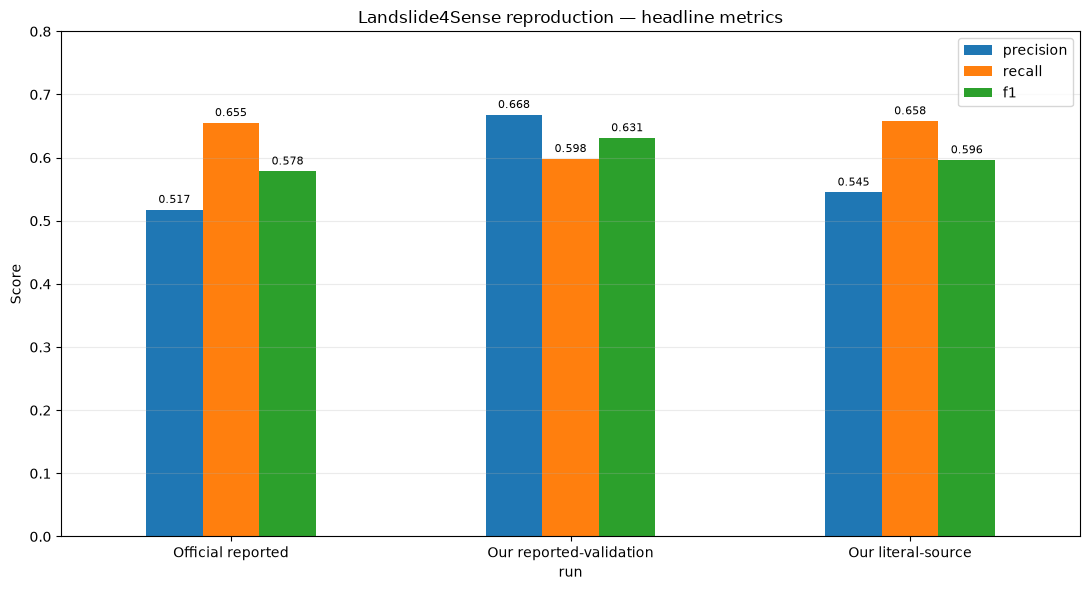

In [119]:

plot_df = l4s_summary.set_index("run")[["precision","recall","f1"]]

ax = plot_df.plot(kind="bar", figsize=(11, 6), rot=0)
ax.set_title("Landslide4Sense reproduction — headline metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.8)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIGDIR / "l4s_headline_metrics.png", dpi=180, bbox_inches="tight")
plt.show()


### A2. Absolute difference from the published baseline

,run,precision_delta,recall_delta,f1_delta
0,Our reported-validation,0.1502,0.0570,0.0527
1,Our literal-source,0.0274,0.0027,0.0178


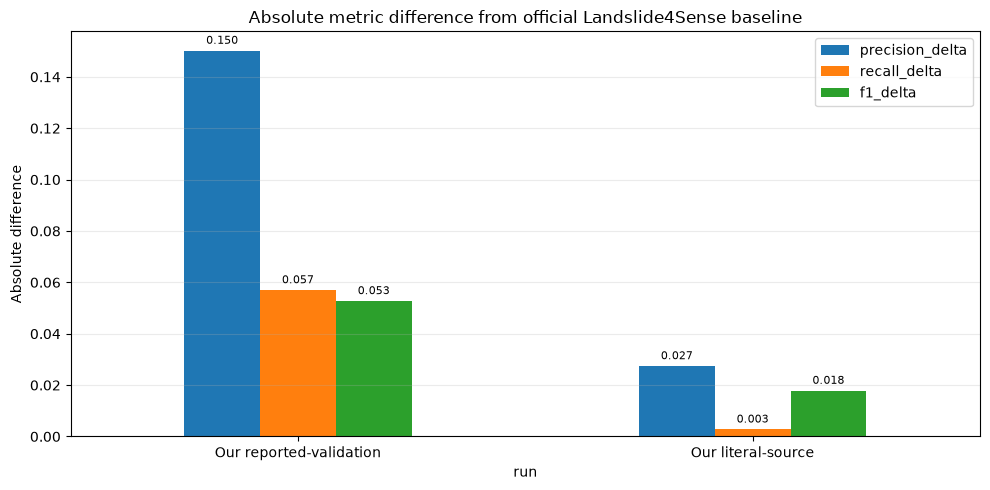

In [120]:

delta_rows = []

for _, r in l4s_summary.iterrows():
    if r["run"] == "Official reported":
        continue
    delta_rows.append({
        "run": r["run"],
        "precision_delta": abs(r["precision"] - OFFICIAL["precision"]),
        "recall_delta": abs(r["recall"] - OFFICIAL["recall"]),
        "f1_delta": abs(r["f1"] - OFFICIAL["f1"]),
    })

delta_df = pd.DataFrame(delta_rows)
display(delta_df.round(4))

if not delta_df.empty:
    ax = delta_df.set_index("run").plot(kind="bar", figsize=(10,5), rot=0)
    ax.set_title("Absolute metric difference from official Landslide4Sense baseline")
    ax.set_ylabel("Absolute difference")
    ax.grid(axis="y", alpha=0.25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_absolute_metric_delta.png", dpi=180, bbox_inches="tight")
    plt.show()


### A3. Literal-source pooled confusion matrix

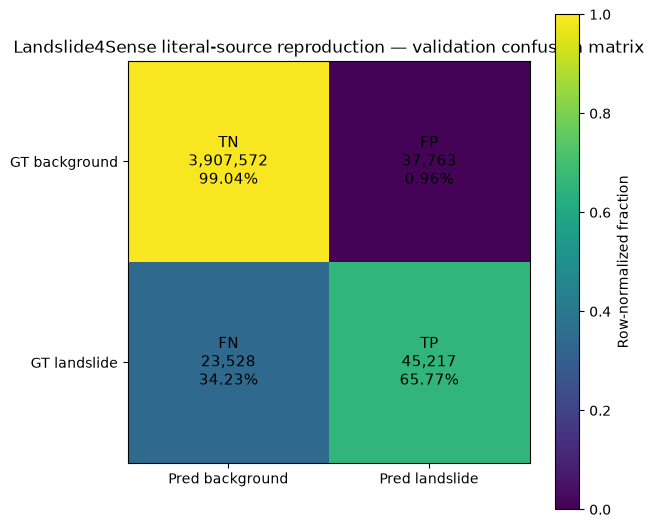

In [121]:

def plot_confusion(tp, fp, fn, tn, title, filename):
    cm = np.array([[tn, fp], [fn, tp]], dtype=np.float64)
    cm_row = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm_row, vmin=0, vmax=1)
    ax.set_xticks([0,1], ["Pred background", "Pred landslide"])
    ax.set_yticks([0,1], ["GT background", "GT landslide"])
    ax.set_title(title)

    labels = [
        [f"TN\n{int(tn):,}\n{cm_row[0,0]:.2%}", f"FP\n{int(fp):,}\n{cm_row[0,1]:.2%}"],
        [f"FN\n{int(fn):,}\n{cm_row[1,0]:.2%}", f"TP\n{int(tp):,}\n{cm_row[1,1]:.2%}"],
    ]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels[i][j], ha="center", va="center", fontsize=11)

    fig.colorbar(im, ax=ax, label="Row-normalized fraction")
    plt.tight_layout()
    plt.savefig(FIGDIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

if literal_obj is not None:
    m = literal_obj["validation"]
    plot_confusion(
        m["tp"], m["fp"], m["fn"], m["tn"],
        "Landslide4Sense literal-source reproduction — validation confusion matrix",
        "l4s_literal_confusion_matrix.png"
    )


### A4. Precision–recall operating points

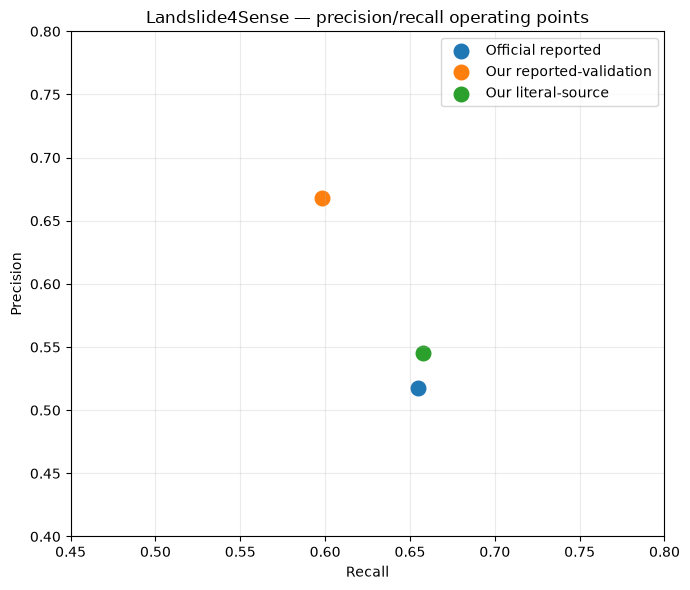

In [122]:

fig, ax = plt.subplots(figsize=(7,6))

ax.scatter([OFFICIAL["recall"]], [OFFICIAL["precision"]], s=110, label="Official reported")

if reported_obj is not None:
    m = reported_obj["validation"]
    ax.scatter([m["recall"]], [m["precision"]], s=110, label="Our reported-validation")

if literal_obj is not None:
    m = literal_obj["validation"]
    ax.scatter([m["recall"]], [m["precision"]], s=110, label="Our literal-source")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Landslide4Sense — precision/recall operating points")
ax.set_xlim(0.45, 0.8)
ax.set_ylim(0.4, 0.8)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.savefig(FIGDIR / "l4s_precision_recall_points.png", dpi=180, bbox_inches="tight")
plt.show()


## B. Landslide4Sense — training history

In [123]:

def read_history(path):
    if not path.exists():
        print("Missing:", path)
        return None
    return pd.read_csv(path)

hist_reported = read_history(L4S_REPORTED_HISTORY)
hist_literal = read_history(L4S_LITERAL_HISTORY)

for name, h in [("reported-validation", hist_reported), ("literal-source", hist_literal)]:
    if h is not None:
        print(name, h.shape)
        print("columns:", h.columns.tolist())


reported-validation (5000, 13)
columns: ['eval_f1', 'eval_fn', 'eval_fp', 'eval_iou', 'eval_overall_accuracy', 'eval_precision', 'eval_recall', 'eval_tn', 'eval_tp', 'step', 'step_seconds', 'train_batch_oa', 'train_loss']
literal-source (5000, 13)
columns: ['eval_f1', 'eval_fn', 'eval_fp', 'eval_iou', 'eval_overall_accuracy', 'eval_precision', 'eval_recall', 'eval_tn', 'eval_tp', 'step', 'step_seconds', 'train_batch_oa', 'train_loss']


### B1. Training loss over optimizer steps

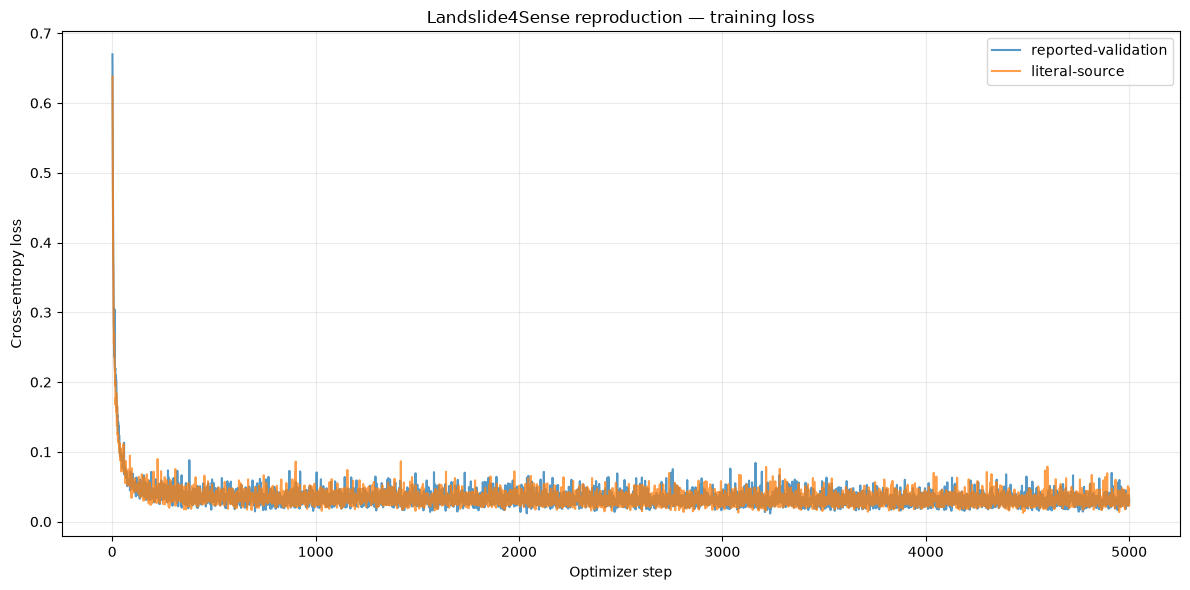

In [124]:

fig, ax = plt.subplots(figsize=(12,6))

if hist_reported is not None and "train_loss" in hist_reported:
    ax.plot(hist_reported["step"], hist_reported["train_loss"], alpha=0.75, label="reported-validation")

if hist_literal is not None and "train_loss" in hist_literal:
    ax.plot(hist_literal["step"], hist_literal["train_loss"], alpha=0.75, label="literal-source")

ax.set_xlabel("Optimizer step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Landslide4Sense reproduction — training loss")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_training_loss.png", dpi=180, bbox_inches="tight")
plt.show()


### B2. Evaluation F1 at checkpoint-selection steps

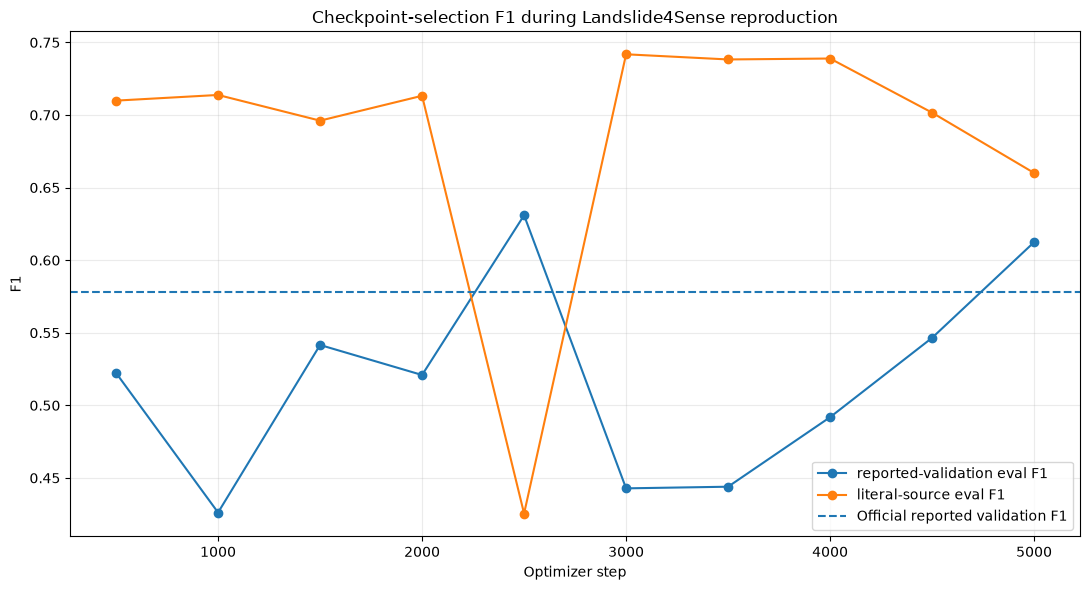

,step,train_loss,eval_precision,eval_recall,eval_f1,eval_iou
499,500,0.0235,0.7730,0.6563,0.7099,0.5503
999,1000,0.0404,0.7803,0.6578,0.7138,0.5550
1499,1500,0.0352,0.8066,0.6123,0.6961,0.5339
1999,2000,0.0368,0.7871,0.6521,0.7132,0.5543
2499,2500,0.0215,0.9424,0.2748,0.4255,0.2702
2999,3000,0.0284,0.7758,0.7107,0.7418,0.5896
3499,3500,0.0334,0.7613,0.7166,0.7383,0.5851
3999,4000,0.0265,0.7297,0.7484,0.7389,0.5859
4499,4500,0.0417,0.8482,0.5982,0.7016,0.5404
4999,5000,0.0231,0.8969,0.5222,0.6601,0.4926


In [125]:

def sparse_eval_frame(h):
    if h is None or "eval_f1" not in h.columns:
        return None
    x = h[h["eval_f1"].notna()].copy()
    return x

er = sparse_eval_frame(hist_reported)
el = sparse_eval_frame(hist_literal)

fig, ax = plt.subplots(figsize=(11,6))

if er is not None and not er.empty:
    ax.plot(er["step"], er["eval_f1"], marker="o", label="reported-validation eval F1")

if el is not None and not el.empty:
    ax.plot(el["step"], el["eval_f1"], marker="o", label="literal-source eval F1")

ax.axhline(OFFICIAL["f1"], linestyle="--", label="Official reported validation F1")
ax.set_xlabel("Optimizer step")
ax.set_ylabel("F1")
ax.set_title("Checkpoint-selection F1 during Landslide4Sense reproduction")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_checkpoint_selection_f1.png", dpi=180, bbox_inches="tight")
plt.show()

if el is not None:
    display(el[[c for c in ["step","train_loss","eval_precision","eval_recall","eval_f1","eval_iou"] if c in el.columns]].round(4))



**Interpretation caution:** in the `literal-source` reproduction, the periodic evaluation used for checkpoint selection mirrors the official source-code behavior and therefore evaluates the training list. The final reported value in `metrics.json` is the selected checkpoint evaluated on the actual validation labels.


## C. Landslide4Sense — per-image validation analysis

In [126]:

def read_mask(path):
    with h5py.File(path, "r") as hf:
        if "mask" in hf:
            arr = hf["mask"][:]
        else:
            keys = list(hf.keys())
            arr = hf[keys[0]][:]
    arr = np.asarray(arr)
    return np.squeeze(arr)

def numeric_id(path):
    digits = "".join(c for c in path.stem if c.isdigit())
    return int(digits) if digits else 10**12

def per_image_metrics(gt_dir, pred_dir):
    rows = []
    for gt_path in sorted(gt_dir.glob("mask_*.h5"), key=numeric_id):
        pred_path = pred_dir / gt_path.name
        if not pred_path.exists():
            continue

        gt = read_mask(gt_path)
        pred = read_mask(pred_path)

        valid = (gt >= 0) & (gt < 2)
        truth = gt == 1
        pos = pred == 1

        tp = int((pos & truth & valid).sum())
        fp = int((pos & ~truth & valid).sum())
        fn = int((~pos & truth & valid).sum())
        tn = int((~pos & ~truth & valid).sum())

        def ratio(a,b):
            return a/b if b else np.nan

        p = ratio(tp, tp+fp)
        r = ratio(tp, tp+fn)
        f1 = ratio(2*tp, 2*tp+fp+fn)
        iou = ratio(tp, tp+fp+fn)

        rows.append({
            "mask": gt_path.name,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision": p, "recall": r, "f1": f1, "iou": iou,
            "gt_positive_fraction": truth[valid].mean(),
            "pred_positive_fraction": pos[valid].mean(),
        })
    return pd.DataFrame(rows)

literal_per_image = None
reported_per_image = None

if L4S_LITERAL_PRED.exists() and L4S_GT_DIR.exists():
    literal_per_image = per_image_metrics(L4S_GT_DIR, L4S_LITERAL_PRED)
    print("Literal per-image rows:", len(literal_per_image))

if L4S_REPORTED_PRED.exists() and L4S_GT_DIR.exists():
    reported_per_image = per_image_metrics(L4S_GT_DIR, L4S_REPORTED_PRED)
    print("Reported-validation per-image rows:", len(reported_per_image))


Literal per-image rows: 245
Reported-validation per-image rows: 245


### C1. Distribution of per-image F1

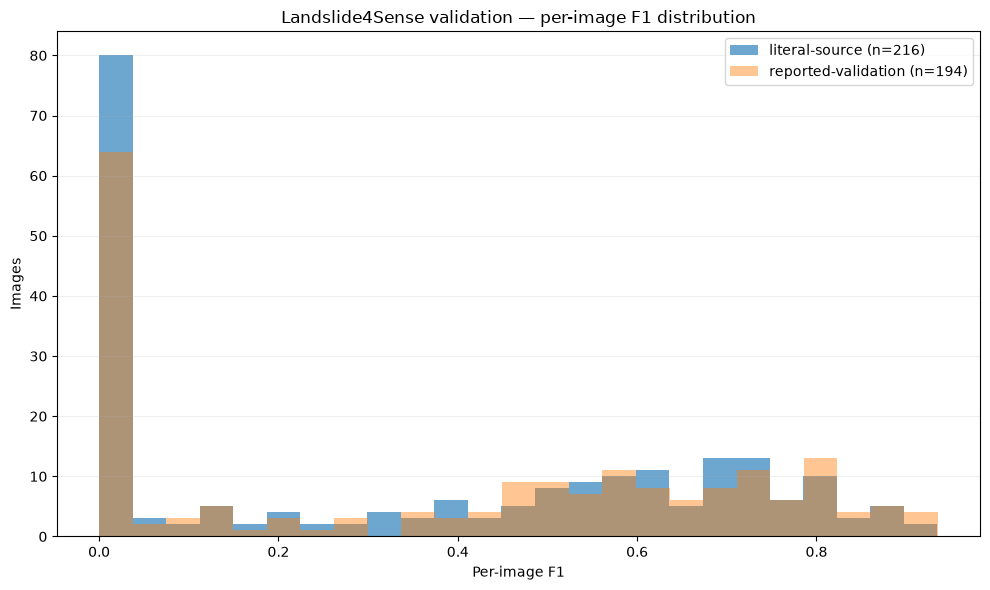

,precision,recall,f1,iou,gt_positive_fraction,pred_positive_fraction
count,210.0000,146.0000,216.0000,216.0000,245.0000,245.0000
mean,0.3654,0.6400,0.3532,0.2644,0.0171,0.0207
std,0.3340,0.2793,0.3215,0.2598,0.0608,0.0477
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.4824,0.0000,0.0000,0.0000,0.0010
50%,0.3772,0.7186,0.3847,0.2382,0.0021,0.0068
75%,0.6743,0.8571,0.6540,0.4859,0.0148,0.0270
max,1.0000,1.0000,0.9347,0.8775,0.6165,0.5041


In [127]:

fig, ax = plt.subplots(figsize=(10,6))

if literal_per_image is not None:
    vals = literal_per_image["f1"].dropna()
    ax.hist(vals, bins=25, alpha=0.65, label=f"literal-source (n={len(vals)})")

if reported_per_image is not None:
    vals = reported_per_image["f1"].dropna()
    ax.hist(vals, bins=25, alpha=0.45, label=f"reported-validation (n={len(vals)})")

ax.set_xlabel("Per-image F1")
ax.set_ylabel("Images")
ax.set_title("Landslide4Sense validation — per-image F1 distribution")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(FIGDIR / "l4s_per_image_f1_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

if literal_per_image is not None:
    display(literal_per_image[["precision","recall","f1","iou","gt_positive_fraction","pred_positive_fraction"]].describe().round(4))


### C2. F1 versus landslide prevalence

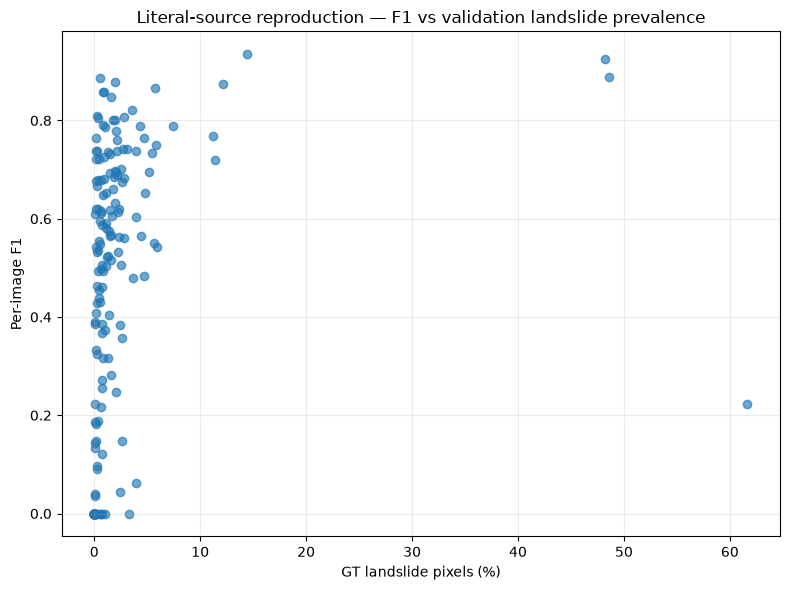

In [128]:

if literal_per_image is not None:
    d = literal_per_image.replace([np.inf,-np.inf], np.nan).dropna(subset=["f1","gt_positive_fraction"])

    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(100*d["gt_positive_fraction"], d["f1"], alpha=0.65)
    ax.set_xlabel("GT landslide pixels (%)")
    ax.set_ylabel("Per-image F1")
    ax.set_title("Literal-source reproduction — F1 vs validation landslide prevalence")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "l4s_f1_vs_gt_prevalence.png", dpi=180, bbox_inches="tight")
    plt.show()


### C3. Best / worst validation images

In [129]:

if literal_per_image is not None:
    valid_f1 = literal_per_image.dropna(subset=["f1"]).copy()

    print("Lowest F1:")
    display(valid_f1.nsmallest(10, "f1")[["mask","f1","precision","recall","fp","fn","gt_positive_fraction","pred_positive_fraction"]].round(4))

    print("Highest F1:")
    display(valid_f1.nlargest(10, "f1")[["mask","f1","precision","recall","fp","fn","gt_positive_fraction","pred_positive_fraction"]].round(4))

    valid_f1.to_csv(FIGDIR / "l4s_literal_per_image_metrics.csv", index=False)


Lowest F1:


,mask,f1,precision,recall,fp,fn,gt_positive_fraction,pred_positive_fraction
0,mask_1.h5,0.0,0.0,NaN,209,0,0.0000,0.0128
11,mask_12.h5,0.0,0.0,NaN,1,0,0.0000,0.0001
12,mask_13.h5,0.0,0.0,NaN,1395,0,0.0000,0.0851
16,mask_17.h5,0.0,0.0,0.0,6,8,0.0005,0.0004
21,mask_22.h5,0.0,0.0,NaN,39,0,0.0000,0.0024
22,mask_23.h5,0.0,0.0,NaN,61,0,0.0000,0.0037
24,mask_25.h5,0.0,0.0,NaN,57,0,0.0000,0.0035
26,mask_27.h5,0.0,0.0,NaN,3,0,0.0000,0.0002
29,mask_30.h5,0.0,0.0,NaN,35,0,0.0000,0.0021
30,mask_31.h5,0.0,0.0,NaN,55,0,0.0000,0.0034


Highest F1:


,mask,f1,precision,recall,fp,fn,gt_positive_fraction,pred_positive_fraction
166,mask_167.h5,0.9347,0.9124,0.9582,218,99,0.1446,0.1519
50,mask_51.h5,0.9257,0.9820,0.8756,127,982,0.4818,0.4296
151,mask_152.h5,0.8890,0.8727,0.9059,1051,749,0.4857,0.5041
64,mask_65.h5,0.8865,0.8817,0.8913,11,10,0.0056,0.0057
168,mask_169.h5,0.8784,0.8253,0.9388,65,20,0.0200,0.0227
222,mask_223.h5,0.8739,0.8209,0.9342,406,131,0.1216,0.1384
104,mask_105.h5,0.8658,0.8382,0.8954,162,98,0.0572,0.0611
146,mask_147.h5,0.8588,0.7760,0.9613,43,6,0.0095,0.0117
35,mask_36.h5,0.8571,0.7582,0.9857,44,2,0.0085,0.0111
231,mask_232.h5,0.8480,0.7676,0.9472,76,14,0.0162,0.0200


## D. Landslide4Sense — qualitative prediction maps

Selected examples: ['mask_1.h5', 'mask_12.h5', 'mask_19.h5', 'mask_132.h5', 'mask_167.h5', 'mask_51.h5']


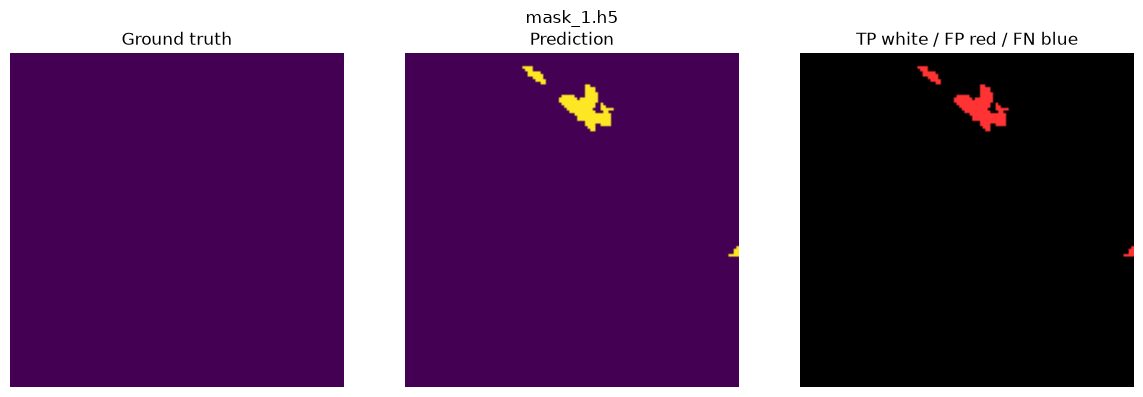

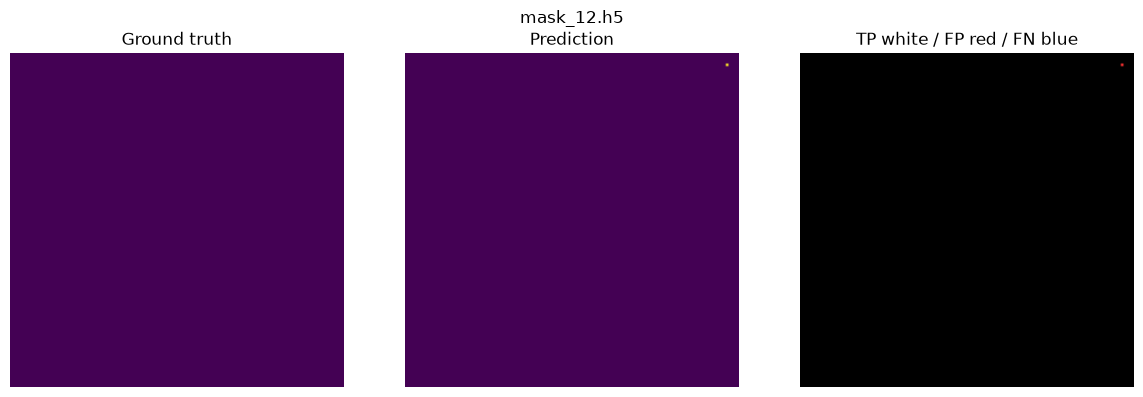

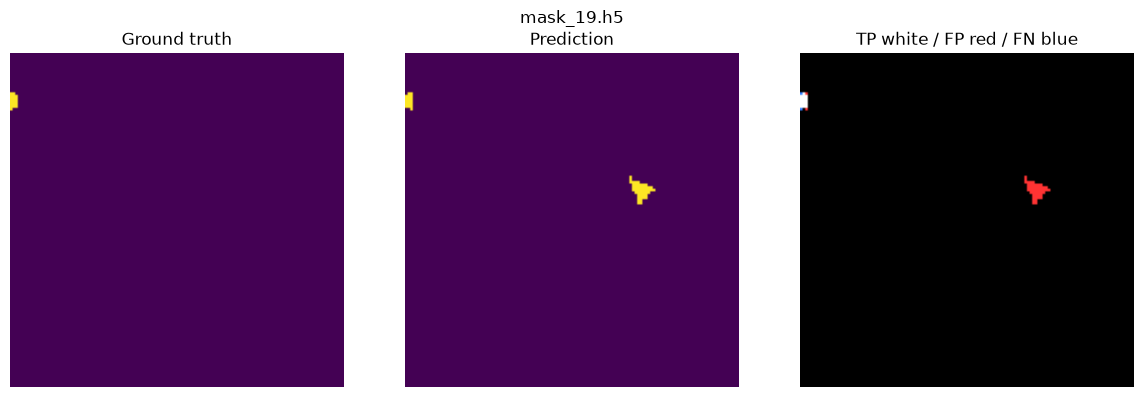

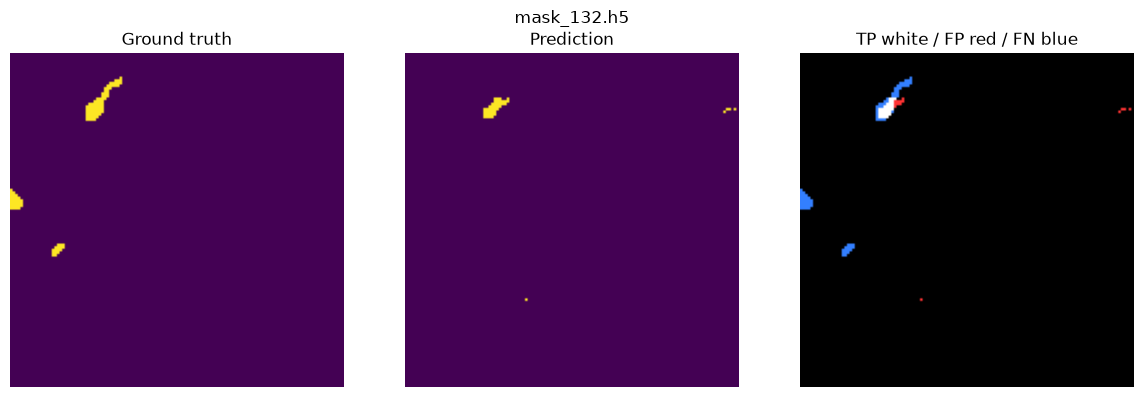

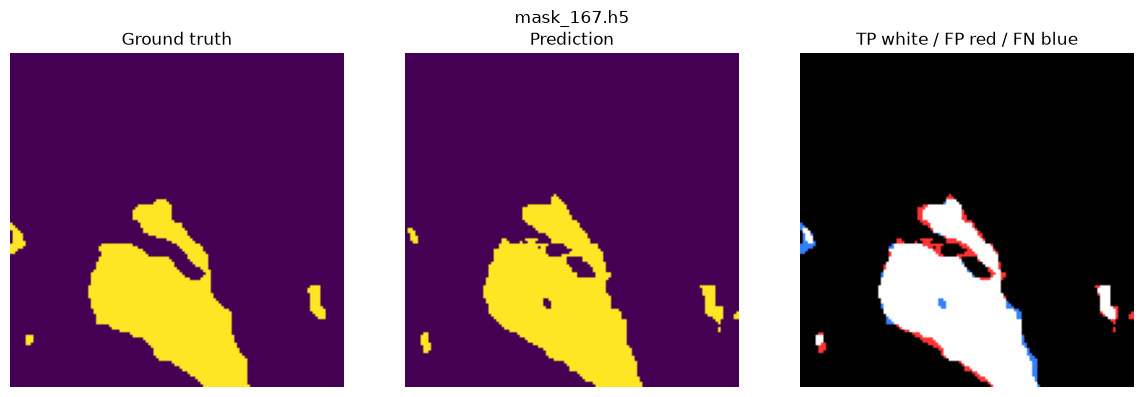

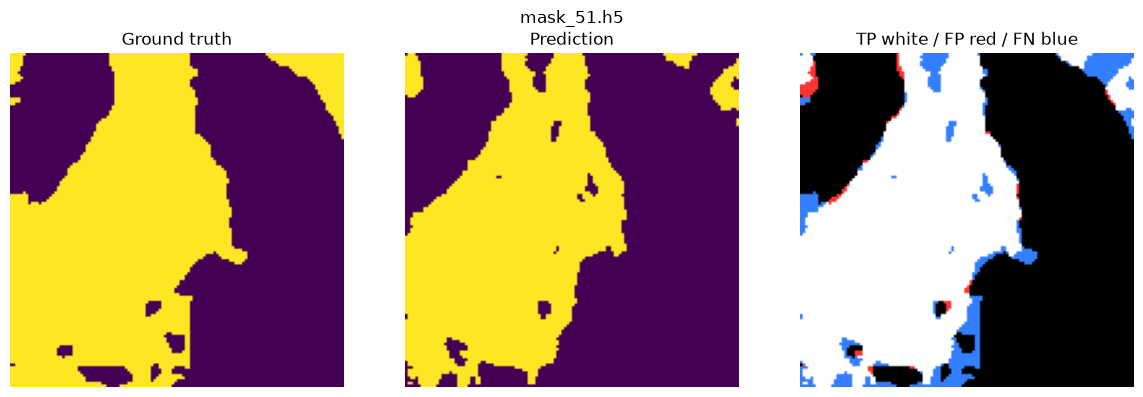

In [130]:

def corresponding_image(mask_name):
    return L4S_IMAGE_DIR / mask_name.replace("mask_", "image_", 1)

def read_image(path):
    with h5py.File(path, "r") as hf:
        if "img" in hf:
            arr = hf["img"][:]
        else:
            arr = hf[list(hf.keys())[0]][:]
    return np.asarray(arr)

def choose_examples(df, n_each=2):
    df = df.dropna(subset=["f1"])
    chosen = []
    chosen += df.nsmallest(n_each, "f1")["mask"].tolist()

    mid = df.iloc[(df["f1"] - df["f1"].median()).abs().argsort()[:n_each]]
    chosen += mid["mask"].tolist()

    chosen += df.nlargest(n_each, "f1")["mask"].tolist()

    # Preserve order, remove duplicates
    return list(dict.fromkeys(chosen))

def show_prediction_example(mask_name, pred_dir, save=True):
    gt = read_mask(L4S_GT_DIR / mask_name)
    pred = read_mask(pred_dir / mask_name)

    err = np.zeros((*gt.shape, 3), dtype=np.float32)
    # TP = white
    tp = (gt == 1) & (pred == 1)
    # FP = red-ish
    fp = (gt == 0) & (pred == 1)
    # FN = blue-ish
    fn = (gt == 1) & (pred == 0)

    err[tp] = [1.0, 1.0, 1.0]
    err[fp] = [1.0, 0.2, 0.2]
    err[fn] = [0.2, 0.5, 1.0]

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].imshow(gt, vmin=0, vmax=1)
    axes[0].set_title("Ground truth")
    axes[1].imshow(pred, vmin=0, vmax=1)
    axes[1].set_title("Prediction")
    axes[2].imshow(err)
    axes[2].set_title("TP white / FP red / FN blue")

    for ax in axes:
        ax.axis("off")

    fig.suptitle(mask_name)
    plt.tight_layout()

    if save:
        plt.savefig(FIGDIR / f"qual_{Path(mask_name).stem}.png", dpi=180, bbox_inches="tight")
    plt.show()

if literal_per_image is not None:
    examples = choose_examples(literal_per_image, n_each=2)
    print("Selected examples:", examples)

    for mask_name in examples:
        show_prediction_example(mask_name, L4S_LITERAL_PRED)


### D1. Optional: inspect all 14 input channels for a selected validation image

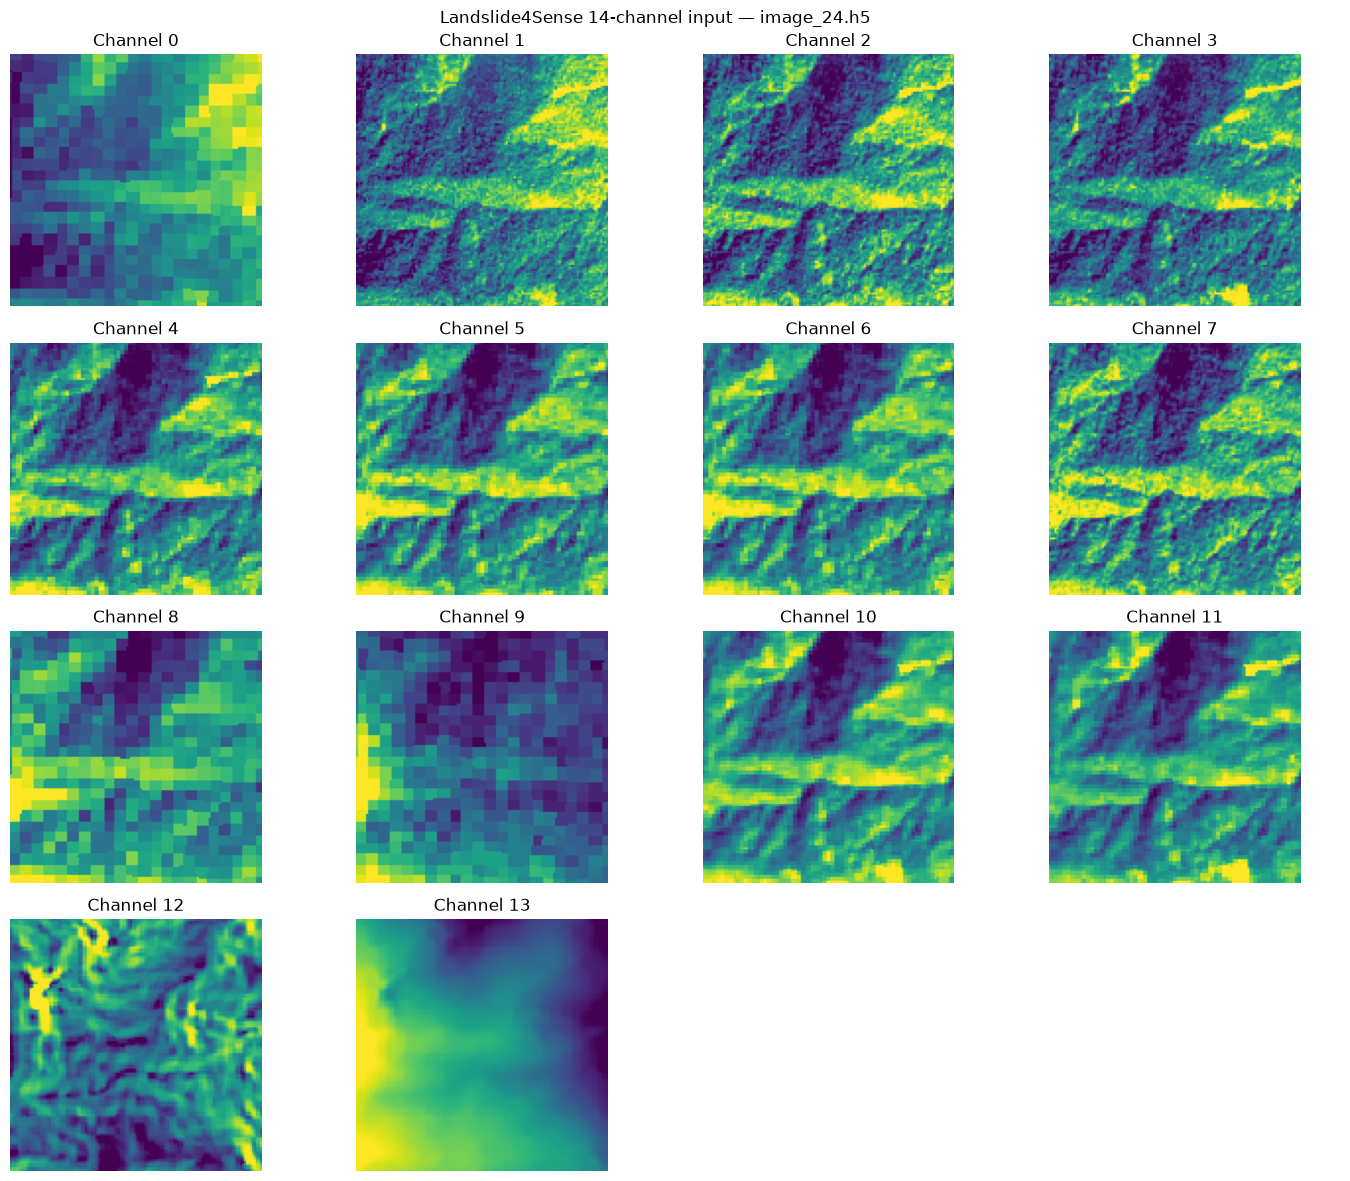

In [131]:

# Landslide4Sense channel semantic names can vary by documentation/version.
# To avoid inventing unsupported names, this notebook labels them Channel 0..13
# unless you replace these labels with the exact dataset documentation.

if literal_per_image is not None and len(literal_per_image):
    mask_name = literal_per_image.dropna(subset=["f1"]).sort_values("f1").iloc[len(literal_per_image)//2]["mask"]
    image_path = corresponding_image(mask_name)

    if image_path.exists():
        image = read_image(image_path)

        # Expect H,W,14 in the public mirror.
        if image.shape[-1] == 14:
            channels = image
        elif image.shape[0] == 14:
            channels = np.moveaxis(image, 0, -1)
        else:
            channels = None

        if channels is not None:
            fig, axes = plt.subplots(4,4, figsize=(14,12))
            axes = axes.ravel()

            for c in range(14):
                x = channels[..., c]
                lo, hi = np.nanpercentile(x, [2,98])
                axes[c].imshow(x, vmin=lo, vmax=hi)
                axes[c].set_title(f"Channel {c}")
                axes[c].axis("off")

            for c in range(14,16):
                axes[c].axis("off")

            fig.suptitle(f"Landslide4Sense 14-channel input — {image_path.name}")
            plt.tight_layout()
            plt.savefig(FIGDIR / "l4s_14channel_example.png", dpi=180, bbox_inches="tight")
            plt.show()


## E. Prediction agreement: reported-validation vs literal-source reproduction

In [132]:

def prediction_agreement(dir_a, dir_b):
    files_a = {p.name:p for p in dir_a.glob("mask_*.h5")}
    files_b = {p.name:p for p in dir_b.glob("mask_*.h5")}
    names = sorted(set(files_a) & set(files_b), key=lambda x: int("".join(c for c in Path(x).stem if c.isdigit())))

    total = equal = a_pos_b_neg = a_neg_b_pos = both_pos = 0

    for name in names:
        a = read_mask(files_a[name])
        b = read_mask(files_b[name])

        total += a.size
        equal += int((a == b).sum())
        both_pos += int(((a == 1) & (b == 1)).sum())
        a_pos_b_neg += int(((a == 1) & (b == 0)).sum())
        a_neg_b_pos += int(((a == 0) & (b == 1)).sum())

    return {
        "common_files": len(names),
        "pixel_agreement": equal / total if total else np.nan,
        "pixel_disagreement": 1 - equal / total if total else np.nan,
        "both_positive": both_pos,
        "reported_pos_literal_neg": a_pos_b_neg,
        "reported_neg_literal_pos": a_neg_b_pos,
    }

if L4S_REPORTED_PRED.exists() and L4S_LITERAL_PRED.exists():
    agree = prediction_agreement(L4S_REPORTED_PRED, L4S_LITERAL_PRED)
    display(pd.Series(agree))


common_files                  245.000000
pixel_agreement                 0.992709
pixel_disagreement              0.007291
both_positive               57640.000000
reported_pos_literal_neg     3928.000000
reported_neg_literal_pos    25340.000000
dtype: float64

## F. Tillamook — frozen development results

In [133]:

comparison_path = TILLAMOOK_PHASE4 / "comparison.csv"

if comparison_path.exists():
    till = pd.read_csv(comparison_path).sort_values("dice", ascending=False).reset_index(drop=True)
else:
    # Fallback to the measured results currently recorded in the project notes.
    till = pd.DataFrame([
        {"run":"deep_7ch","architecture":"deep","features":"7ch","parameters":7767137,"best_epoch":21,"threshold":0.45,
         "dice":0.4085,"iou":0.2567,"precision":0.2961,"recall":0.6584,"specificity":0.7396,
         "fp":13034704,"fn":2844173,"predicted_positive_fraction":0.3171,"gt_positive_fraction":0.1426},
        {"run":"deep_3ch","architecture":"deep","features":"3ch","parameters":7765985,"best_epoch":26,"threshold":0.50,
         "dice":0.3434,"iou":0.2073,"precision":0.2327,"recall":0.6543,"specificity":0.6412,
         "fp":17962608,"fn":2878302,"predicted_positive_fraction":0.4009,"gt_positive_fraction":0.1426},
        {"run":"shallow_7ch","architecture":"shallow","features":"7ch","parameters":468961,"best_epoch":21,"threshold":0.50,
         "dice":0.3228,"iou":0.1924,"precision":0.2105,"recall":0.6919,"specificity":0.5683,
         "fp":21611982,"fn":2565382,"predicted_positive_fraction":0.4688,"gt_positive_fraction":0.1426},
        {"run":"shallow_3ch","architecture":"shallow","features":"3ch","parameters":467809,"best_epoch":4,"threshold":0.45,
         "dice":0.2901,"iou":0.1696,"precision":0.1826,"recall":0.7051,"specificity":0.4750,
         "fp":26286768,"fn":2455430,"predicted_positive_fraction":0.5507,"gt_positive_fraction":0.1426},
    ])

display(till.round(4))


,run,architecture,features,parameters,best_epoch,threshold,dice,iou,precision,recall,specificity,fp,fn,gt_positive_fraction,predicted_positive_fraction,pos_weight
0,deep_7ch,Deep,7ch,7767137,21,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,13034704,2844173,0.1426,0.3171,4.5964
1,deep_3ch,Deep,3ch,7765985,26,0.50,0.3434,0.2073,0.2327,0.6543,0.6412,17962608,2878302,0.1426,0.4009,4.5964
2,shallow_7ch,Shallow,7ch,468961,21,0.50,0.3228,0.1924,0.2105,0.6919,0.5683,21611982,2565382,0.1426,0.4688,4.5964
3,shallow_3ch,Shallow,3ch,467809,4,0.45,0.2901,0.1696,0.1826,0.7051,0.4750,26286768,2455430,0.1426,0.5507,4.5964


### F1. 2×2 metric comparison

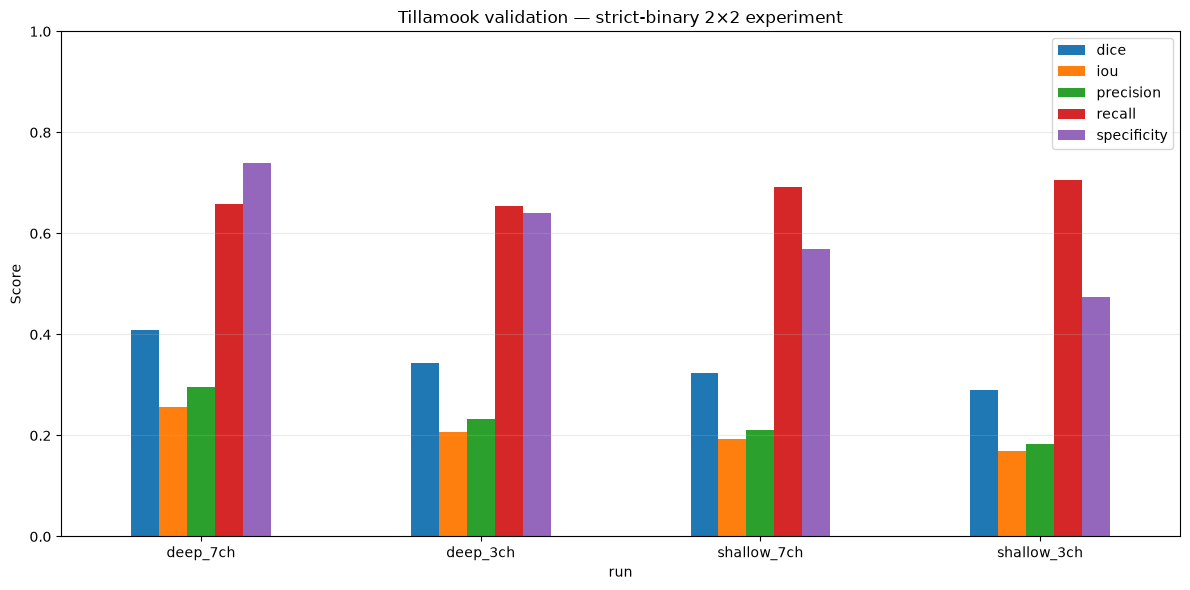

In [134]:

metric_cols = ["dice","iou","precision","recall","specificity"]

ax = till.set_index("run")[metric_cols].plot(kind="bar", figsize=(12,6), rot=0)
ax.set_title("Tillamook validation — strict-binary 2×2 experiment")
ax.set_ylabel("Score")
ax.set_ylim(0,1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "tillamook_2x2_metrics.png", dpi=180, bbox_inches="tight")
plt.show()


### F2. GT-positive vs predicted-positive area

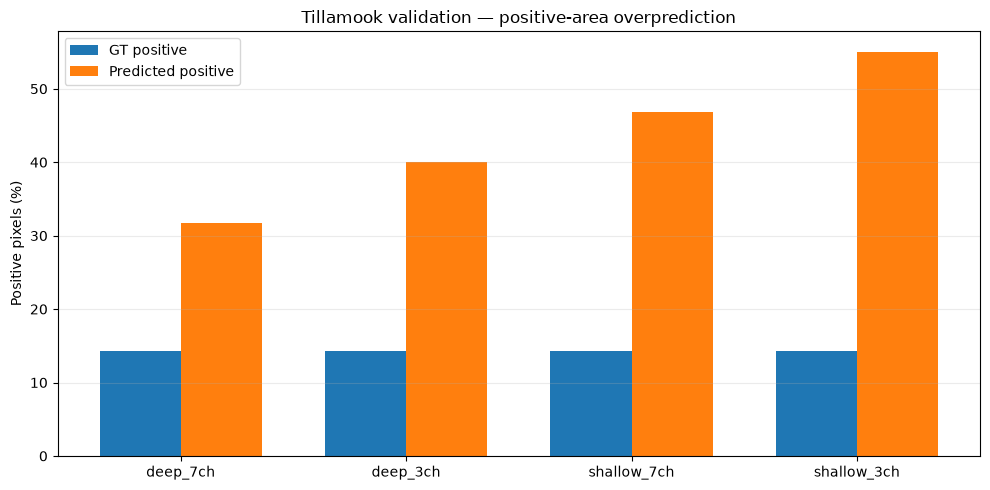

,run,gt_positive_fraction,predicted_positive_fraction,overprediction_ratio
0,deep_7ch,0.143,0.317,2.224
1,deep_3ch,0.143,0.401,2.811
2,shallow_7ch,0.143,0.469,3.287
3,shallow_3ch,0.143,0.551,3.862


In [135]:

if "gt_positive_fraction" in till.columns and "predicted_positive_fraction" in till.columns:
    x = np.arange(len(till))
    w = 0.36

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(x-w/2, 100*till["gt_positive_fraction"], width=w, label="GT positive")
    ax.bar(x+w/2, 100*till["predicted_positive_fraction"], width=w, label="Predicted positive")
    ax.set_xticks(x)
    ax.set_xticklabels(till["run"])
    ax.set_ylabel("Positive pixels (%)")
    ax.set_title("Tillamook validation — positive-area overprediction")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_positive_area.png", dpi=180, bbox_inches="tight")
    plt.show()

    over = till[["run","gt_positive_fraction","predicted_positive_fraction"]].copy()
    over["overprediction_ratio"] = over["predicted_positive_fraction"] / over["gt_positive_fraction"]
    display(over.round(3))


### F3. FP / FN burden

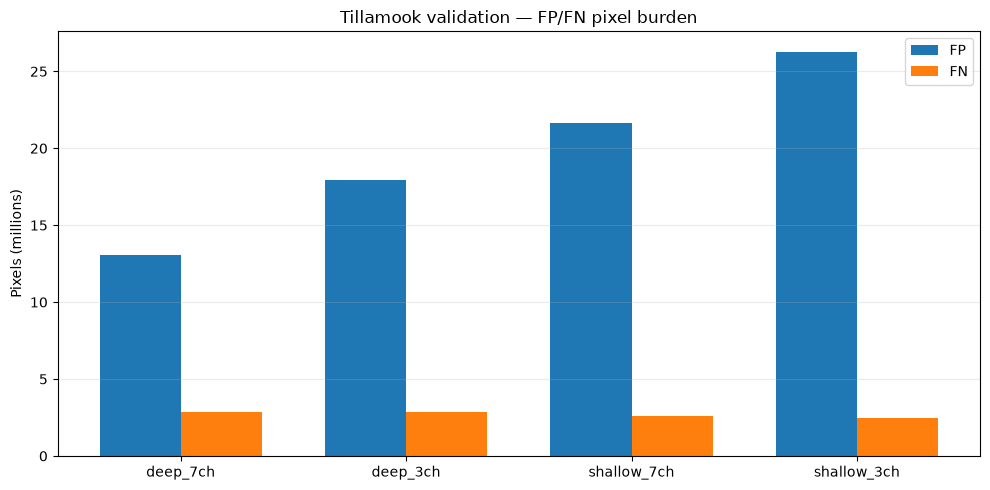

In [136]:

if {"fp","fn"} <= set(till.columns):
    x = np.arange(len(till))
    w = 0.36

    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(x-w/2, till["fp"]/1e6, width=w, label="FP")
    ax.bar(x+w/2, till["fn"]/1e6, width=w, label="FN")
    ax.set_xticks(x)
    ax.set_xticklabels(till["run"])
    ax.set_ylabel("Pixels (millions)")
    ax.set_title("Tillamook validation — FP/FN pixel burden")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_fp_fn.png", dpi=180, bbox_inches="tight")
    plt.show()


## G. Tillamook — training histories

In [137]:

till_hist = {}

for name, run_dir in TILLAMOOK_RUNS.items():
    p = run_dir / "history.csv"
    if p.exists():
        till_hist[name] = pd.read_csv(p)
        print(name, till_hist[name].shape)
    else:
        print("Missing history:", p)


shallow_7ch (50, 15)
shallow_3ch (50, 15)
deep_7ch (50, 15)
deep_3ch (50, 15)


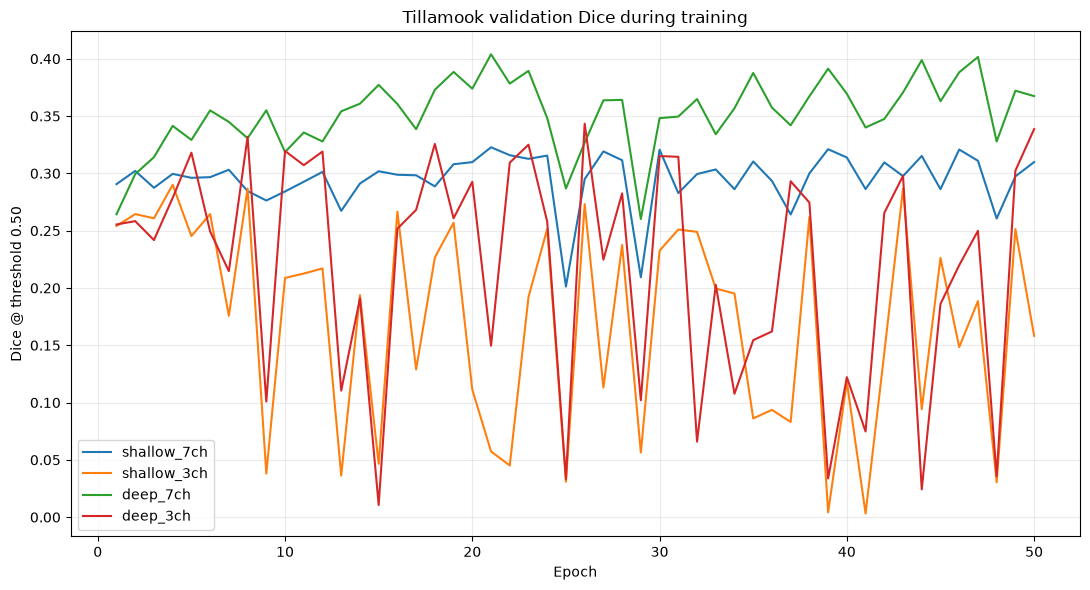

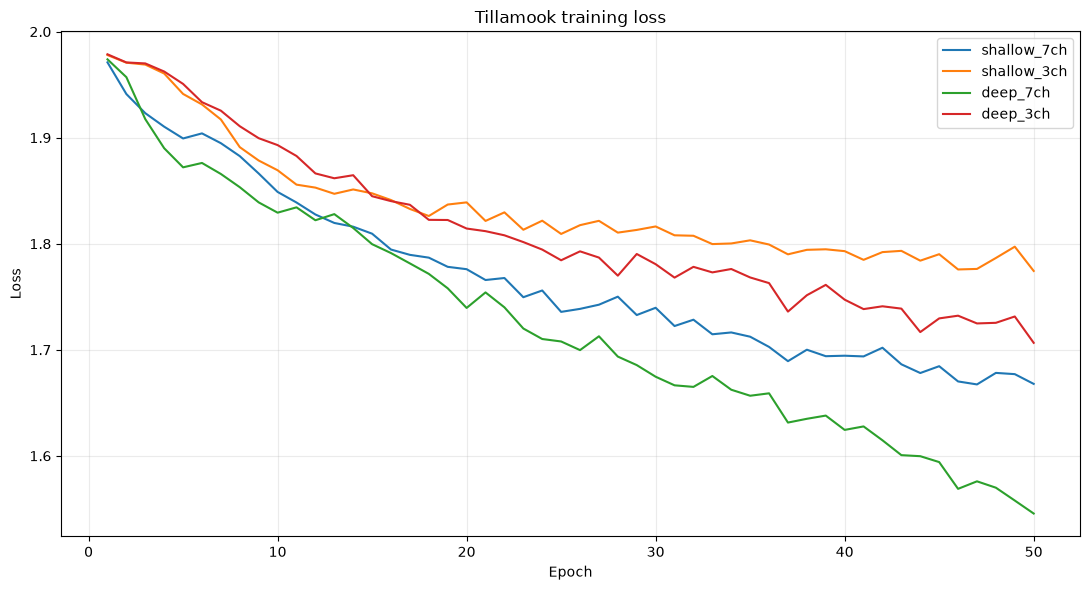

In [138]:

if till_hist:
    fig, ax = plt.subplots(figsize=(11,6))
    for name, h in till_hist.items():
        possible = [c for c in h.columns if "validation" in c.lower() and "dice" in c.lower()]
        if possible:
            ax.plot(h["epoch"], h[possible[0]], label=name)

    ax.set_title("Tillamook validation Dice during training")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Dice @ threshold 0.50")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_training_val_dice.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(11,6))
    for name, h in till_hist.items():
        if "train_loss" in h:
            ax.plot(h["epoch"], h["train_loss"], label=name)

    ax.set_title("Tillamook training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_training_loss.png", dpi=180, bbox_inches="tight")
    plt.show()


## H. Tillamook — threshold sweeps

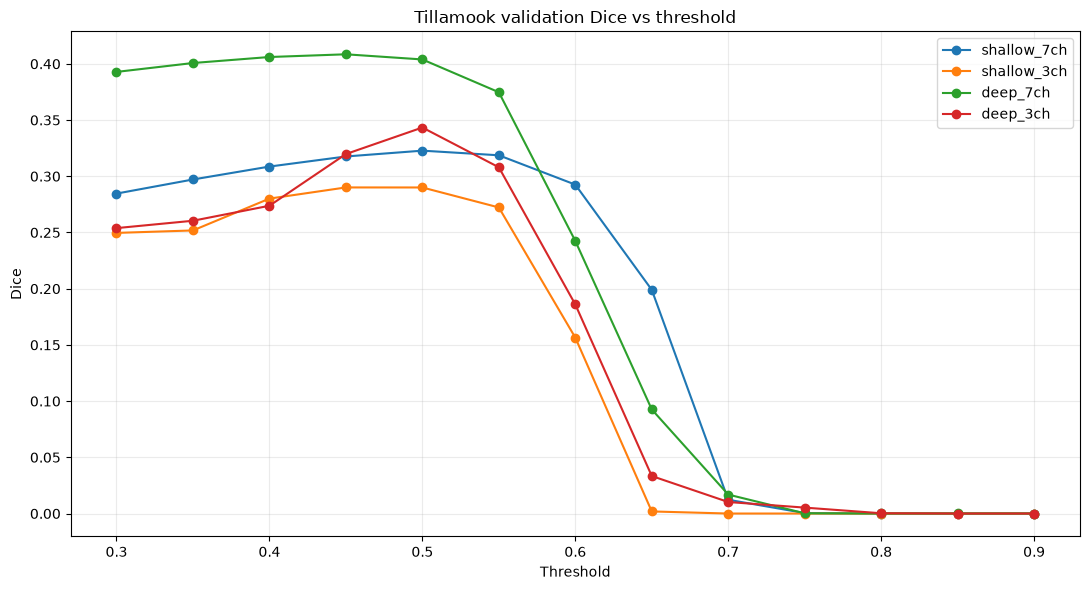

In [139]:

sweeps = {}

for name, run_dir in TILLAMOOK_RUNS.items():
    p = run_dir / "validation_threshold_sweep.csv"
    if p.exists():
        sweeps[name] = pd.read_csv(p)

if sweeps:
    fig, ax = plt.subplots(figsize=(11,6))
    for name, s in sweeps.items():
        ax.plot(s["threshold"], s["dice"], marker="o", label=name)

    ax.set_title("Tillamook validation Dice vs threshold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Dice")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_threshold_dice.png", dpi=180, bbox_inches="tight")
    plt.show()


### H1. Deep 7ch operating-point trade-off

,threshold,dice,iou,precision,recall,specificity,gt_positive_fraction,predicted_positive_fraction,fp,fn
0,0.30,0.3928,0.2444,0.2599,0.8038,0.6194,0.1426,0.4410,19056625,1634054
1,0.35,0.4007,0.2506,0.2720,0.7609,0.6612,0.1426,0.3990,16960360,1990657
2,0.40,0.4061,0.2548,0.2835,0.7151,0.6995,0.1426,0.3596,15045267,2372648
3,0.45,0.4085,0.2567,0.2961,0.6584,0.7396,0.1426,0.3171,13034704,2844173
4,0.50,0.4039,0.2531,0.3114,0.5746,0.7887,0.1426,0.2631,10580399,3542390
5,0.55,0.3747,0.2306,0.3321,0.4300,0.8561,0.1426,0.1847,7203212,4746140
6,0.60,0.2425,0.1380,0.3470,0.1863,0.9417,0.1426,0.0766,2919381,6775487
7,0.65,0.0926,0.0485,0.3587,0.0532,0.9842,0.1426,0.0211,791424,7884443
8,0.70,0.0169,0.0085,0.3693,0.0086,0.9976,0.1426,0.0033,122627,8255267
9,0.75,0.0002,0.0001,0.3187,0.0001,1.0000,0.1426,0.0000,1836,8326212


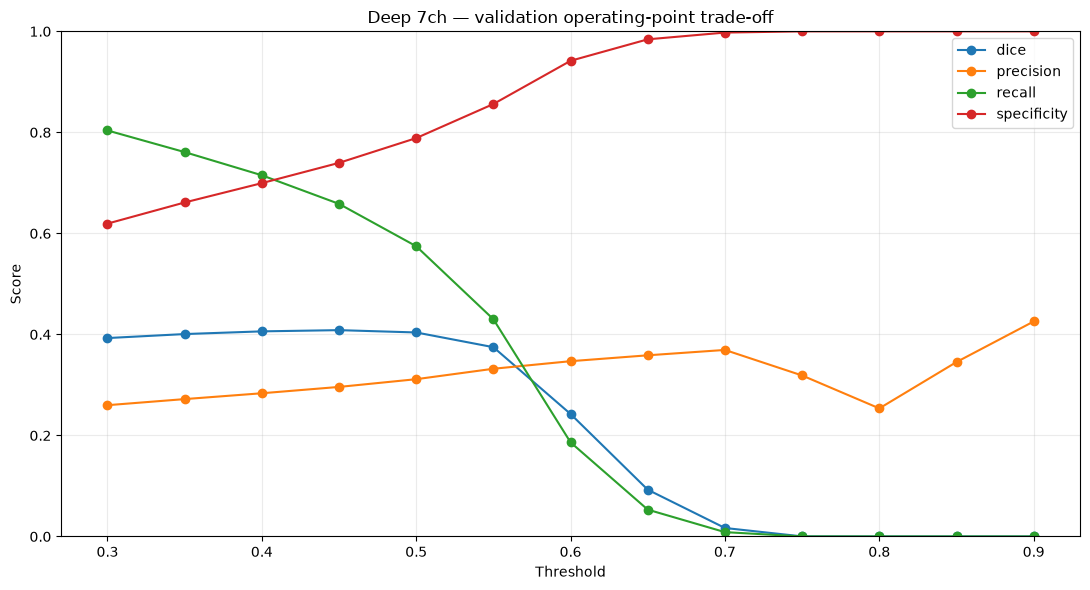

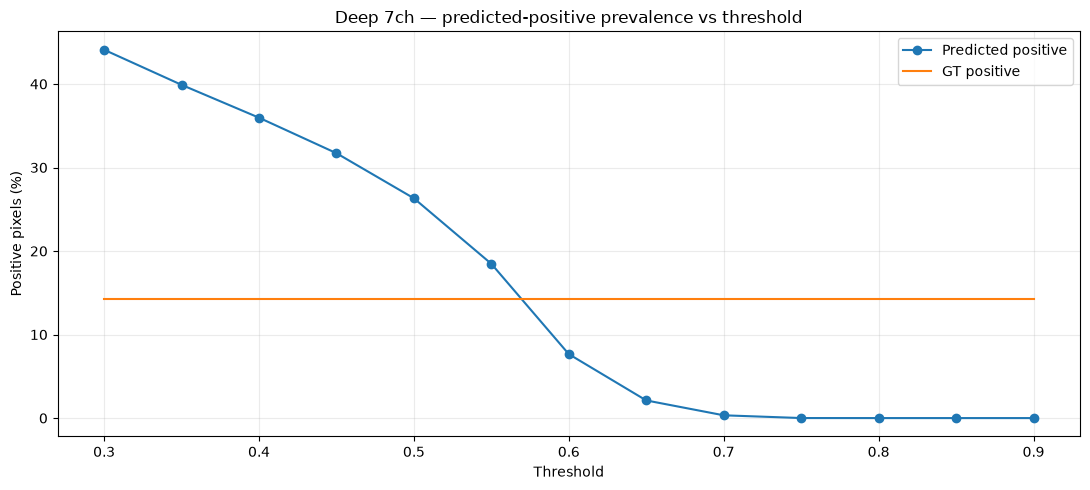

In [140]:

deep7 = sweeps.get("deep_7ch")

if deep7 is not None:
    keep = [c for c in [
        "threshold","dice","iou","precision","recall","specificity",
        "gt_positive_fraction","predicted_positive_fraction","fp","fn"
    ] if c in deep7.columns]

    display(deep7[keep].round(4))

    fig, ax = plt.subplots(figsize=(11,6))
    for metric in ["dice","precision","recall","specificity"]:
        if metric in deep7:
            ax.plot(deep7["threshold"], deep7[metric], marker="o", label=metric)

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title("Deep 7ch — validation operating-point trade-off")
    ax.set_ylim(0,1)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGDIR / "tillamook_deep7_threshold_tradeoff.png", dpi=180, bbox_inches="tight")
    plt.show()

    if {"gt_positive_fraction","predicted_positive_fraction"} <= set(deep7.columns):
        fig, ax = plt.subplots(figsize=(11,5))
        ax.plot(deep7["threshold"], 100*deep7["predicted_positive_fraction"], marker="o", label="Predicted positive")
        ax.plot(deep7["threshold"], 100*deep7["gt_positive_fraction"], label="GT positive")
        ax.set_xlabel("Threshold")
        ax.set_ylabel("Positive pixels (%)")
        ax.set_title("Deep 7ch — predicted-positive prevalence vs threshold")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIGDIR / "tillamook_deep7_positive_prevalence_threshold.png", dpi=180, bbox_inches="tight")
        plt.show()


## I. Public benchmark vs Tillamook — debugging context only


**Do not interpret this section as a direct model-performance benchmark.**

Landslide4Sense and Tillamook differ in:

- input modalities/channels,
- patch size,
- dataset construction,
- landslide prevalence,
- architecture,
- loss,
- class weighting,
- checkpoint selection,
- thresholding,
- geographic distribution.

The purpose here is only to make the debugging result visually obvious: the generic segmentation pipeline can reproduce a known public landslide baseline, while the Tillamook terrain-only task remains substantially harder / more over-segmented.


,experiment,precision,recall,f1_or_dice,iou
0,Landslide4Sense literal reproduction,0.5449,0.6577,0.5960,0.4245
1,Tillamook deep_7ch,0.2961,0.6584,0.4085,0.2567


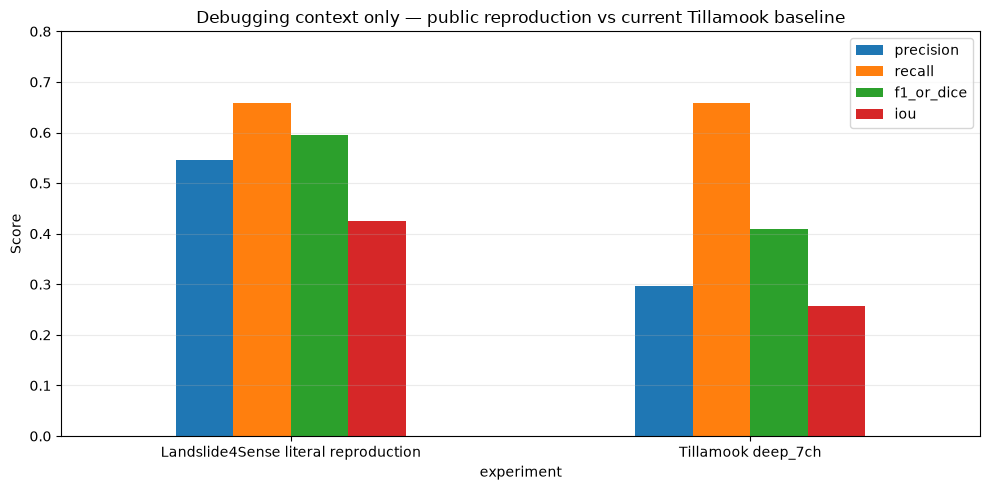

In [141]:

context_rows = []

if literal_obj is not None:
    m = literal_obj["validation"]
    context_rows.append({
        "experiment": "Landslide4Sense literal reproduction",
        "precision": m["precision"],
        "recall": m["recall"],
        "f1_or_dice": m["f1"],
        "iou": m["iou"],
    })

if not till.empty:
    best = till.sort_values("dice", ascending=False).iloc[0]
    context_rows.append({
        "experiment": f"Tillamook {best['run']}",
        "precision": best["precision"],
        "recall": best["recall"],
        "f1_or_dice": best["dice"],
        "iou": best["iou"],
    })

context = pd.DataFrame(context_rows)
display(context.round(4))

if len(context):
    ax = context.set_index("experiment")[["precision","recall","f1_or_dice","iou"]].plot(
        kind="bar", figsize=(10,5), rot=0
    )
    ax.set_title("Debugging context only — public reproduction vs current Tillamook baseline")
    ax.set_ylabel("Score")
    ax.set_ylim(0,0.8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGDIR / "context_public_vs_tillamook.png", dpi=180, bbox_inches="tight")
    plt.show()


## J. Automatic summary

In [142]:

summary_lines = []

if literal_obj is not None:
    m = literal_obj["validation"]
    summary_lines.append(
        f"Landslide4Sense literal-source reproduction: "
        f"P={m['precision']:.4f}, R={m['recall']:.4f}, F1={m['f1']:.4f}, IoU={m['iou']:.4f}."
    )
    summary_lines.append(
        f"Absolute difference from official reference: "
        f"ΔP={abs(m['precision']-OFFICIAL['precision']):.4f}, "
        f"ΔR={abs(m['recall']-OFFICIAL['recall']):.4f}, "
        f"ΔF1={abs(m['f1']-OFFICIAL['f1']):.4f}."
    )

if not till.empty:
    best = till.sort_values("dice", ascending=False).iloc[0]
    summary_lines.append(
        f"Tillamook current validation winner: {best['run']} "
        f"(Dice={best['dice']:.4f}, IoU={best['iou']:.4f}, "
        f"P={best['precision']:.4f}, R={best['recall']:.4f})."
    )
    if "predicted_positive_fraction" in best and "gt_positive_fraction" in best:
        summary_lines.append(
            f"Tillamook positive-area prevalence: "
            f"GT={100*best['gt_positive_fraction']:.2f}% vs "
            f"predicted={100*best['predicted_positive_fraction']:.2f}%."
        )

summary_lines.append("Tillamook internal test remains locked and is not loaded by this notebook.")

for line in summary_lines:
    print("•", line)

(ROOT / "analysis_figures_full" / "analysis_summary.txt").write_text(
    "\n".join(summary_lines),
    encoding="utf-8"
)


• Landslide4Sense literal-source reproduction: P=0.5449, R=0.6577, F1=0.5960, IoU=0.4245.
• Absolute difference from official reference: ΔP=0.0274, ΔR=0.0027, ΔF1=0.0178.
• Tillamook current validation winner: deep_7ch (Dice=0.4085, IoU=0.2567, P=0.2961, R=0.6584).
• Tillamook positive-area prevalence: GT=14.26% vs predicted=31.71%.
• Tillamook internal test remains locked and is not loaded by this notebook.


401


## Outputs

All generated PNG figures and CSV summaries are saved under:

```text
F:\LIDAR\oregon\analysis_figures_full\
```

Recommended figures to show the professor first:

1. `l4s_headline_metrics.png`
2. `l4s_checkpoint_selection_f1.png`
3. `l4s_literal_confusion_matrix.png`
4. `tillamook_2x2_metrics.png`
5. `tillamook_positive_area.png`
6. `tillamook_deep7_threshold_tradeoff.png`
7. selected `qual_mask_*.png` examples
8. `context_public_vs_tillamook.png` — debugging context only, not a formal benchmark comparison.
